In [51]:
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


i will use the ImageNet-pretrained ResNet

In [3]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
dataset = torchvision.datasets.Caltech101(
    root="./data",
    download=True,
    transform=train_transform
)

print("Number of images:", len(dataset))
print("Number of classes:", len(dataset.categories))
print("Classes:", dataset.categories[:10])

100%|██████████| 137M/137M [00:00<00:00, 178MB/s]


Number of images: 8677
Number of classes: 101
Classes: ['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass']


In [5]:
from torch.utils.data import DataLoader, random_split

total_size = len(dataset)

train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 6073
Validation: 1301
Test: 1303


In [6]:
base_dataset = torchvision.datasets.Caltech101(
    root="./data",
    download=True,
    transform=None
)

indices = torch.randperm(
    len(base_dataset),
    generator=torch.Generator().manual_seed(42)
).tolist()

train_size = int(0.7 * len(indices))
val_size = int(0.15 * len(indices))

In [7]:
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

In [8]:
from torch.utils.data import Subset

train_full = torchvision.datasets.Caltech101(
    root="./data",
    download=False,
    transform=train_transform
)

eval_full = torchvision.datasets.Caltech101(
    root="./data",
    download=False,
    transform=test_transform
)

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(eval_full, val_indices)
test_dataset = Subset(eval_full, test_indices)

print(len(train_dataset), len(val_dataset), len(test_dataset))

6073 1301 1303


In [9]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [10]:
weights = models.ResNet34_Weights.DEFAULT

model = models.resnet34(weights=weights)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 160MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

froze all pretrained convolutional layers except the last one (layer 4)

In [12]:
num_classes = len(base_dataset.categories)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=101, bias=True)


In [13]:
num_classes = len(base_dataset.categories)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=101, bias=True)


In [14]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    loss = running_loss / len(loader)

    return loss, accuracy

In [15]:
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    return loss, accuracy

(i hate training using pytorch :p)

In [16]:
EPOCHS = 10

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_val_acc = 0


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_acc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "resnet34_caltech101_best.pth"
        )

Epoch 1/10 | Train Loss: 1.1911 | Train Acc: 71.35% | Val Loss: 0.5725 | Val Acc: 84.24%
Epoch 2/10 | Train Loss: 0.4304 | Train Acc: 87.40% | Val Loss: 0.3119 | Val Acc: 90.32%
Epoch 3/10 | Train Loss: 0.2468 | Train Acc: 92.47% | Val Loss: 0.3562 | Val Acc: 90.32%
Epoch 4/10 | Train Loss: 0.1832 | Train Acc: 94.55% | Val Loss: 0.2752 | Val Acc: 91.78%
Epoch 5/10 | Train Loss: 0.1459 | Train Acc: 95.75% | Val Loss: 0.3367 | Val Acc: 91.24%
Epoch 6/10 | Train Loss: 0.1229 | Train Acc: 96.11% | Val Loss: 0.2774 | Val Acc: 93.01%
Epoch 7/10 | Train Loss: 0.1026 | Train Acc: 96.76% | Val Loss: 0.2830 | Val Acc: 92.62%
Epoch 8/10 | Train Loss: 0.0649 | Train Acc: 98.14% | Val Loss: 0.2100 | Val Acc: 94.47%
Epoch 9/10 | Train Loss: 0.0865 | Train Acc: 97.60% | Val Loss: 0.2402 | Val Acc: 93.47%
Epoch 10/10 | Train Loss: 0.0965 | Train Acc: 97.45% | Val Loss: 0.3442 | Val Acc: 91.16%


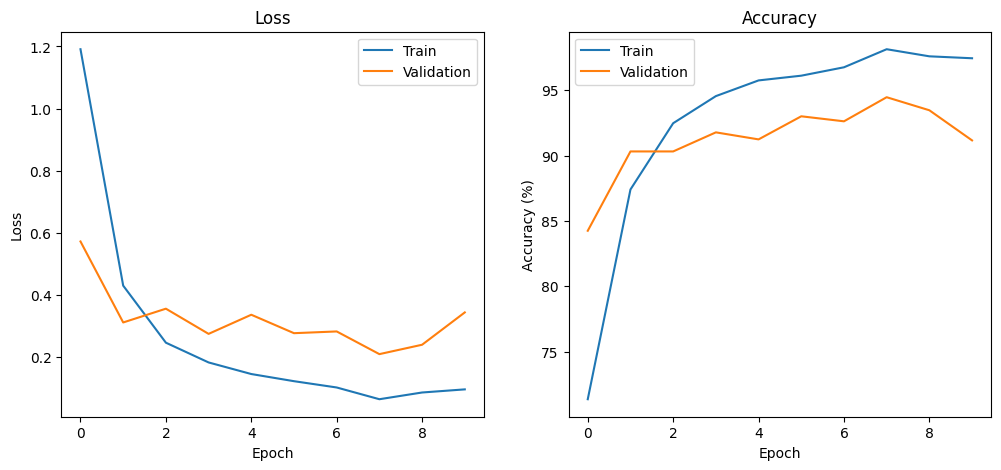

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy")
plt.legend()

plt.show()

too many epochs, the perfect number is 7 to 8 because after that it starts to overfit

# Phase 2: Attack (Fast Gradient Sign Method)

In [18]:
def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach()
    images.requires_grad = True

    outputs = model(images)

    loss = F.cross_entropy(outputs, labels)

    model.zero_grad()

    loss.backward()

    data_grad = images.grad.data

    perturbed_images = images + epsilon * data_grad.sign()

    return perturbed_images.detach()

In [19]:
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

epsilon = 0.01

adv_images = fgsm_attack(
    model,
    images,
    labels,
    epsilon
)

print("Original shape:", images.shape)
print("Adversarial shape:", adv_images.shape)

Original shape: torch.Size([32, 3, 224, 224])
Adversarial shape: torch.Size([32, 3, 224, 224])


In [20]:
def evaluate_adversarial(model, loader, epsilon):
    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        adv_images = fgsm_attack(
            model,
            images,
            labels,
            epsilon
        )

        outputs = model(adv_images)

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [21]:
epsilons = [
    0.001,
    0.003,
    0.005,
    0.01,
    0.02,
    0.05
]

adv_accuracies = []

for eps in epsilons:

    acc = evaluate_adversarial(
        model,
        test_loader,
        eps
    )

    adv_accuracies.append(acc)

    print(
        f"Epsilon = {eps:.3f} | "
        f"Accuracy = {acc:.2f}%"
    )

Epsilon = 0.001 | Accuracy = 84.27%
Epsilon = 0.003 | Accuracy = 68.76%
Epsilon = 0.005 | Accuracy = 54.49%
Epsilon = 0.010 | Accuracy = 29.32%
Epsilon = 0.020 | Accuracy = 14.04%
Epsilon = 0.050 | Accuracy = 7.98%


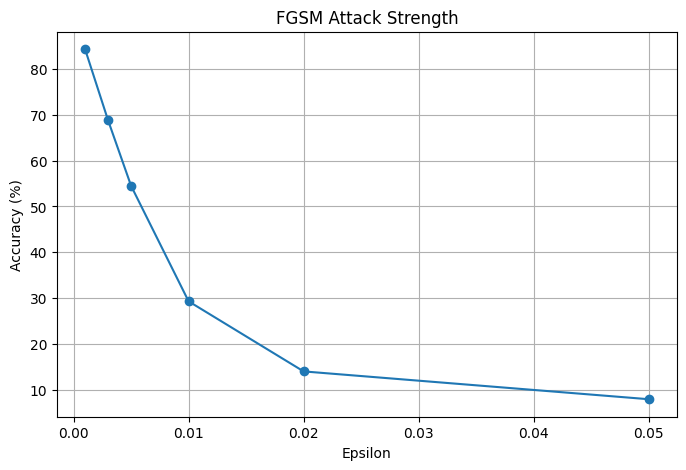

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    epsilons,
    adv_accuracies,
    marker="o"
)

plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.title("FGSM Attack Strength")

plt.grid()
plt.show()

the accuarcy decreases as the epsilon increases

In [27]:
def show_attack(images, adv_images, index=0):

    # Get the selected images
    original = images[index].detach().cpu()
    adversarial = adv_images[index].detach().cpu()

    # ---------------------------------------------------------
    # Denormalize images for correct visualization
    # ---------------------------------------------------------
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    original_display = (
        original * std + mean
    ).clamp(0, 1)

    adversarial_display = (
        adversarial * std + mean
    ).clamp(0, 1)

    # ---------------------------------------------------------
    # Calculate adversarial perturbation
    # ---------------------------------------------------------
    noise = (adversarial - original).abs()

    # Combine RGB channels into one intensity map
    noise = noise.mean(dim=0)

    # Normalize ONLY for visualization
    noise = noise / (noise.max() + 1e-8)

    # ---------------------------------------------------------
    # Convert images from CHW -> HWC
    # ---------------------------------------------------------
    original_display = original_display.permute(1, 2, 0)
    adversarial_display = adversarial_display.permute(1, 2, 0)

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------
    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 5)
    )

    # Original
    axes[0].imshow(original_display)
    axes[0].set_title("Original")

    # Adversarial
    axes[1].imshow(adversarial_display)
    axes[1].set_title("Adversarial")

    # Perturbation
    axes[2].imshow(
        noise,
        cmap="hot"
    )
    axes[2].set_title("Adversarial Perturbation")

    # Remove axes
    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

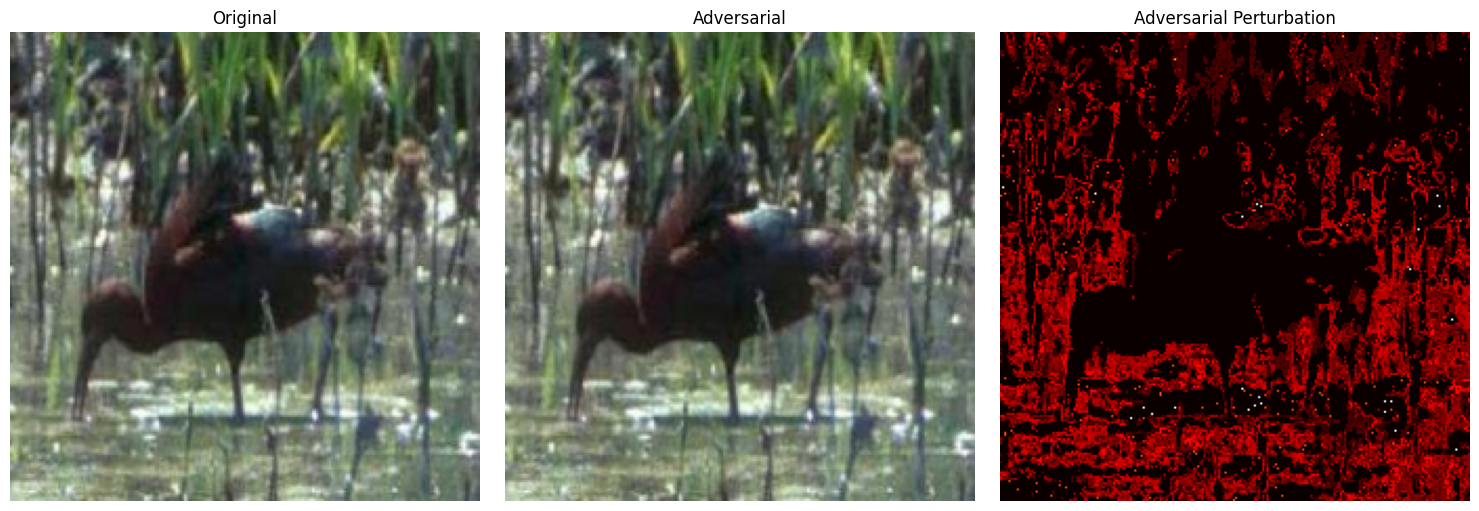

In [28]:
show_attack(images, adv_images)

scary...

# Phase 3: Explainability

## Vanilla Saliency

In [29]:
def saliency_map(model, image, target_class):

    model.eval()

    image = image.clone().detach()
    image.requires_grad = True

    output = model(image)

    score = output[0, target_class]

    model.zero_grad()

    score.backward()

    saliency = image.grad.abs()

    saliency = saliency.max(dim=1)[0]

    saliency = saliency / (
        saliency.max() + 1e-8
    )

    return saliency.detach()

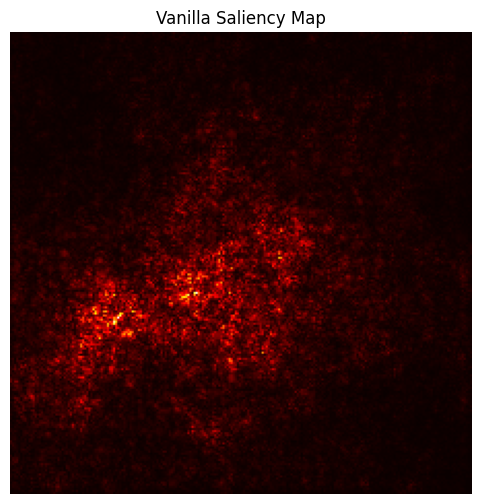

In [30]:
image = images[0:1]
label = labels[0].item()

saliency = saliency_map(
    model,
    image,
    label
)

plt.figure(figsize=(6, 6))

plt.imshow(saliency[0].cpu(), cmap="hot")

plt.axis("off")
plt.title("Vanilla Saliency Map")

plt.show()

## Grad-CAM

In [31]:
class GradCAM:

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(
            self.save_activation
        )

        target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, image, target_class):

        self.model.eval()

        output = self.model(image)

        score = output[0, target_class]

        self.model.zero_grad()

        score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (weights * activations).sum(dim=1)

        cam = F.relu(cam)

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze()

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.detach()

In [32]:
gradcam = GradCAM(
    model,
    model.layer4[-1]
)

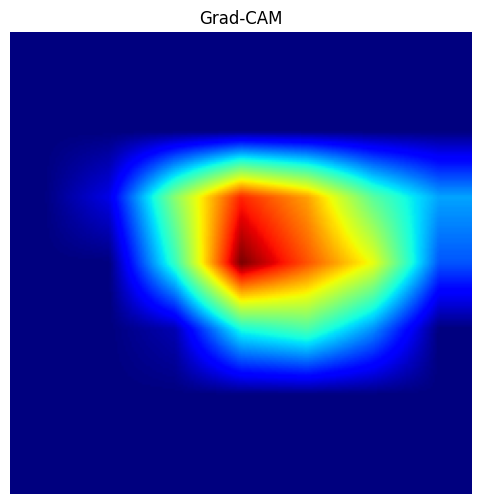

In [33]:
image = images[0:1]

with torch.no_grad():
    output = model(image)

predicted_class = output.argmax(dim=1).item()

cam = gradcam.generate(
    image,
    predicted_class
)

plt.figure(figsize=(6, 6))

plt.imshow(cam.cpu(), cmap="jet")

plt.axis("off")
plt.title("Grad-CAM")

plt.show()

Phase 4: Forensic Analysis

In [34]:
def get_prediction(model, image):

    model.eval()

    with torch.no_grad():

        output = model(image)

        probabilities = F.softmax(
            output,
            dim=1
        )

        confidence, prediction = probabilities.max(1)

    return prediction.item(), confidence.item()

In [35]:
epsilon = 0.01

for i in range(len(images)):

    clean_image = images[i:i+1]
    true_label = labels[i].item()

    clean_pred, clean_conf = get_prediction(
        model,
        clean_image
    )

    if clean_pred != true_label:
        continue

    adv_image = fgsm_attack(
        model,
        clean_image,
        labels[i:i+1],
        epsilon
    )

    adv_pred, adv_conf = get_prediction(
        model,
        adv_image
    )

    if adv_pred != true_label:

        print("Found successful attack!")

        print("True class:", base_dataset.categories[true_label])
        print("Clean prediction:", base_dataset.categories[clean_pred])
        print("Adversarial prediction:", base_dataset.categories[adv_pred])

        break

Found successful attack!
True class: strawberry
Clean prediction: strawberry
Adversarial prediction: stop_sign


i mean both are red haha

In [36]:
clean_saliency = saliency_map(
    model,
    clean_image,
    clean_pred
)

In [37]:
adv_saliency = saliency_map(
    model,
    adv_image,
    adv_pred
)

In [38]:
clean_cam = gradcam.generate(
    clean_image,
    clean_pred
)

In [39]:
adv_cam = gradcam.generate(
    adv_image,
    adv_pred
)

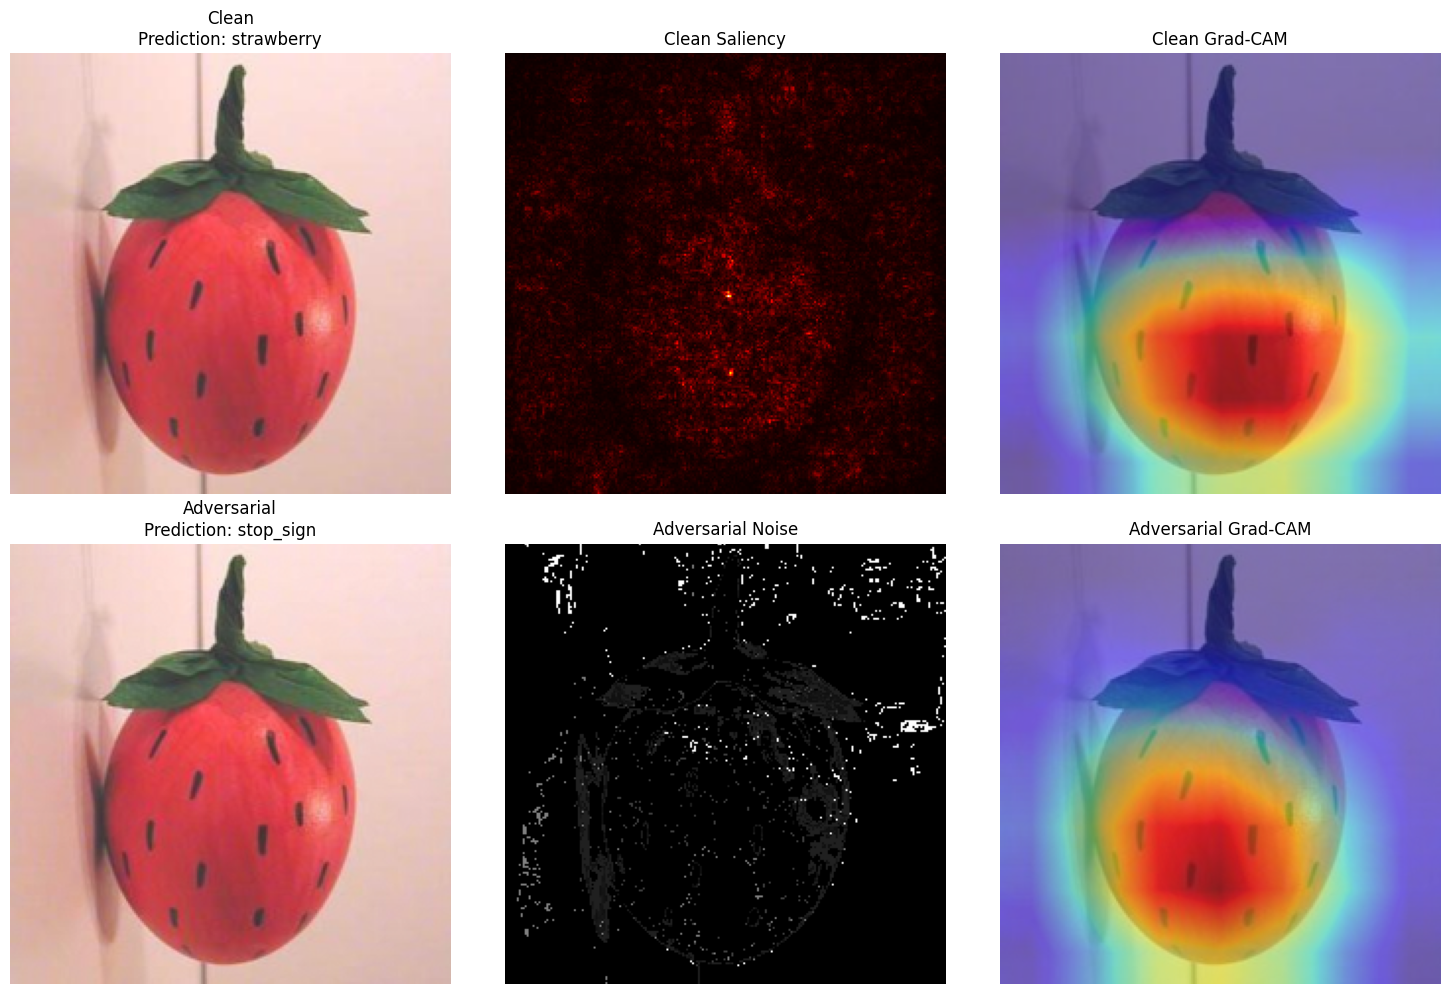

In [40]:
def denormalize(image):

    mean = torch.tensor(
        [0.485, 0.456, 0.406],
        device=image.device
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225],
        device=image.device
    ).view(3, 1, 1)

    return (
        image * std + mean
    ).clamp(0, 1)


clean_display = denormalize(
    clean_image[0]
).permute(1, 2, 0).detach().cpu()

adv_display = denormalize(
    adv_image[0]
).permute(1, 2, 0).detach().cpu()

noise = (
    adv_image[0] - clean_image[0]
).abs().max(dim=0)[0].detach().cpu()


fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 10)
)

# Clean image
axes[0, 0].imshow(clean_display)
axes[0, 0].set_title(
    f"Clean\nPrediction: {base_dataset.categories[clean_pred]}"
)

# Clean saliency
axes[0, 1].imshow(clean_saliency[0].cpu(), cmap="hot")
axes[0, 1].set_title("Clean Saliency")

# Clean GradCAM
axes[0, 2].imshow(clean_display)
axes[0, 2].imshow(
    clean_cam.cpu(),
    cmap="jet",
    alpha=0.5
)
axes[0, 2].set_title("Clean Grad-CAM")

# Adversarial image
axes[1, 0].imshow(adv_display)
axes[1, 0].set_title(
    f"Adversarial\nPrediction: {base_dataset.categories[adv_pred]}"
)

# Noise
axes[1, 1].imshow(noise, cmap="gray")
axes[1, 1].set_title("Adversarial Noise")

# Adversarial GradCAM
axes[1, 2].imshow(adv_display)
axes[1, 2].imshow(
    adv_cam.cpu(),
    cmap="jet",
    alpha=0.5
)
axes[1, 2].set_title("Adversarial Grad-CAM")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Phase 5: Defence

i will create a new model

In [41]:
def create_model(num_classes):

    weights = models.ResNet34_Weights.DEFAULT

    model = models.resnet34(
        weights=weights
    )

    for param in model.parameters():
        param.requires_grad = False


    for param in model.layer4.parameters():
        param.requires_grad = True

    model.fc = nn.Linear(
        model.fc.in_features,
        num_classes
    )

    return model.to(device)

In [42]:
defense_model = create_model(
    num_classes
)

defense_optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        defense_model.parameters()
    ),
    lr=1e-4
)

defense_criterion = nn.CrossEntropyLoss()

In [43]:
def adversarial_train_epoch(
    model,
    loader,
    criterion,
    optimizer,
    epsilon
):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Generate adversarial examples
        adv_images = fgsm_attack(
            model,
            images,
            labels,
            epsilon
        )

        optimizer.zero_grad()

        # Clean predictions
        clean_outputs = model(images)

        # Adversarial predictions
        adv_outputs = model(adv_images)

        clean_loss = criterion(
            clean_outputs,
            labels
        )

        adv_loss = criterion(
            adv_outputs,
            labels
        )

        # Combine both
        loss = (
            clean_loss + adv_loss
        ) / 2

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        _, predicted = clean_outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(
            labels
        ).sum().item()

    accuracy = 100 * correct / total

    return total_loss / len(loader), accuracy

In [44]:
DEFENSE_EPOCHS = 10

defense_epsilon = 0.01

for epoch in range(DEFENSE_EPOCHS):

    loss, acc = adversarial_train_epoch(
        defense_model,
        train_loader,
        defense_criterion,
        defense_optimizer,
        defense_epsilon
    )

    print(
        f"Epoch {epoch+1}/{DEFENSE_EPOCHS} | "
        f"Loss: {loss:.4f} | "
        f"Clean Train Acc: {acc:.2f}%"
    )

Epoch 1/10 | Loss: 2.2590 | Clean Train Acc: 67.45%
Epoch 2/10 | Loss: 0.9564 | Clean Train Acc: 92.80%
Epoch 3/10 | Loss: 0.6504 | Clean Train Acc: 96.20%
Epoch 4/10 | Loss: 0.4870 | Clean Train Acc: 97.58%
Epoch 5/10 | Loss: 0.4016 | Clean Train Acc: 98.27%
Epoch 6/10 | Loss: 0.3440 | Clean Train Acc: 98.52%
Epoch 7/10 | Loss: 0.2950 | Clean Train Acc: 98.73%
Epoch 8/10 | Loss: 0.2503 | Clean Train Acc: 99.08%
Epoch 9/10 | Loss: 0.2178 | Clean Train Acc: 99.13%
Epoch 10/10 | Loss: 0.1972 | Clean Train Acc: 99.21%


In [45]:
defense_clean_loss, defense_clean_acc = evaluate(
    defense_model,
    test_loader,
    criterion
)

print(
    f"Hardened Model Clean Accuracy: "
    f"{defense_clean_acc:.2f}%"
)

Hardened Model Clean Accuracy: 94.70%


In [46]:
defense_adv_acc = evaluate_adversarial(
    defense_model,
    test_loader,
    defense_epsilon
)

print(
    f"Hardened Model Adversarial Accuracy: "
    f"{defense_adv_acc:.2f}%"
)

Hardened Model Adversarial Accuracy: 73.60%


# Conclusion

In [49]:
original_clean_loss, original_clean_acc = evaluate(
    model,
    test_loader,
    criterion
)

original_adv_acc = evaluate_adversarial(
    model,
    test_loader,
    defense_epsilon
)

print(
    f"Original Model - Clean: "
    f"{original_clean_acc:.2f}%"
)

print(
    f"Original Model - Adversarial: "
    f"{original_adv_acc:.2f}%"
)

print(
    f"Hardened Model - Clean: "
    f"{defense_clean_acc:.2f}%"
)

print(
    f"Hardened Model - Adversarial: "
    f"{defense_adv_acc:.2f}%"
)

Original Model - Clean: 91.33%
Original Model - Adversarial: 29.32%
Hardened Model - Clean: 94.70%
Hardened Model - Adversarial: 73.60%


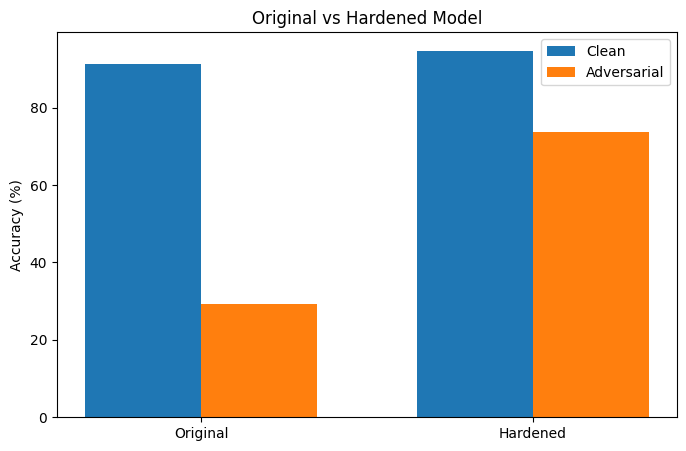

In [52]:
models_names = [
    "Original",
    "Hardened"
]

clean_scores = [
    original_clean_acc,
    defense_clean_acc
]

adv_scores = [
    original_adv_acc,
    defense_adv_acc
]

x = np.arange(len(models_names))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    clean_scores,
    width,
    label="Clean"
)

plt.bar(
    x + width/2,
    adv_scores,
    width,
    label="Adversarial"
)

plt.xticks(
    x,
    models_names
)

plt.ylabel("Accuracy (%)")
plt.title("Original vs Hardened Model")
plt.legend()

plt.show()